In [1]:
from os.path import join 

import matplotlib.pyplot as plt 
import numpy as np 
import tidy3d as td 
from tidy3d import web 
from tidy3d.plugins.resonance import ResonanceFinder

from honeycomb_hex import create_hexagonal_honeycomb_slab
from honeycomb import create_centered_honeycomb_slab

03:04:14 Pacific Daylight Time WARNING: Using canonical configuration directory 
                               at 'C:\Users\xtliang\.config\tidy3d'. Found      
                               legacy directory at '~/.tidy3d', which will be   
                               ignored. Remove it manually or run 'tidy3d config
                               migrate --delete-legacy' to clean up.            

In [2]:
# ── Parameters (match the Lumerical script variables) ────────────────────────
a       = 1.0     # Lattice constant (um)
R       = 15      # Hexagonal radius in unit-cell repeats
radius  = 0.225   # Disk radius (um)  — corresponds to diameter 0.45 um
z_span  = 0.22    # Slab thickness (um)
n_si    = 3.47    # Refractive index of silicon
material = td.Medium(permittivity=n_si**2)

# Twist parameters for double-layer verification
ANGLE   = 0.75    # Twist angle (degrees)
GAP     = 0.3     # Gap between the two slabs (um)

# Randomized source/monitor setup
rng_seed = 20260311
num_sources = 12
num_time_monitors = 12
rand_span_xy = 1.0                 # random x/y range is [-1, 1] um
rand_span_z = GAP + 2 * z_span     # random z range is [-(GAP+2*z_span)/2, +(GAP+2*z_span)/2] um

In [3]:
# cyls_bottom = create_hexagonal_honeycomb_slab(
#     lattice_const=a, disk_radius=radius, slab_thickness=z_span,
#     hex_radius=R, twist_angle=ANGLE, material=material, centerz=-z_span / 2 - GAP / 2,
# )
# cyls_top = create_hexagonal_honeycomb_slab(
#     lattice_const=a, disk_radius=radius, slab_thickness=z_span,
#     hex_radius=R, twist_angle=-ANGLE, material=material, centerz=z_span / 2 + GAP / 2,
# )

cyls_bottom = create_centered_honeycomb_slab(
    lattice_const=a, disk_diameter=2*radius, slab_thickness=z_span,
    twist_angle=0, domain_size=(2*R*a, 2*R*a), material=material, centerz=-z_span / 2 - GAP / 2,
)

cyls_top = create_centered_honeycomb_slab(
    lattice_const=a, disk_diameter=2*radius, slab_thickness=z_span,
    twist_angle=2*ANGLE, domain_size=(2*R*a, 2*R*a), material=material, centerz=z_span / 2 + GAP / 2,
)
# Build a single td.Structure from all cylinders
all_geom = td.GeometryGroup(geometries=cyls_bottom + cyls_top)
structure = td.Structure(geometry=all_geom, medium=material)

In [4]:
# sim size
lx = (R * a) * 2.0 + 4
ly = (R * a) * 2.0 + 3
lz = 4.5  # enlarged to include Gaussian beam waist plane at z = -2 um

Configured 2 GaussianBeam sources for circular polarization.
Beam waist center: (7, 0, -2.0), waist radius: 4.0 um


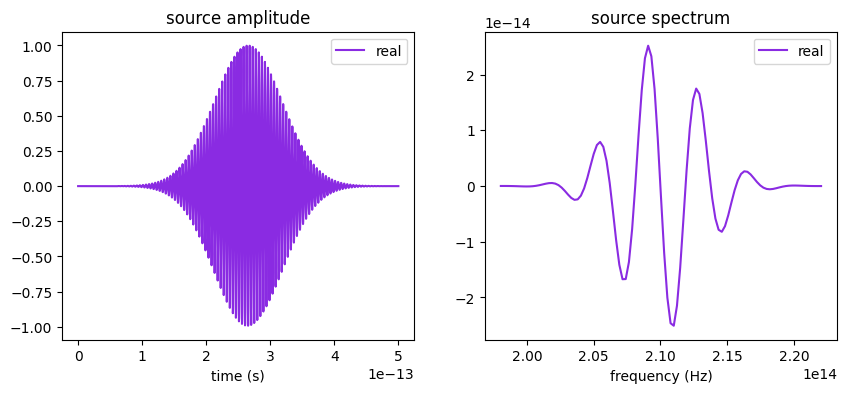

In [5]:
# Central frequency around which we'll look for the cavity mode (Hz)
# wavelength = 1.55
# freq0 = td.C_0 / wavelength
freq0 = 210e12

# Source bandwidth (Hz)
fwidth = 3e12

# Simulation run time (s)
run_time = 5e-12

# RNG remains for downstream randomized monitor placement (unchanged settings).
rng = np.random.default_rng(rng_seed)

# Circularly polarized normally incident Gaussian beam modeled by two orthogonal beams
# on the same source plane with pi/2 phase offset.
beam_center = (7, 0, -2.0)
beam_size = (lx, ly, 0)
beam_waist_radius = 4.0

gaussian_source_x = td.GaussianBeam(
    center=beam_center,
    size=beam_size,
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    direction="+",
    pol_angle=0.0,
    angle_theta=0.0,
    angle_phi=0.0,
    waist_radius=beam_waist_radius,
    waist_distance=0.0,
    name="gaussian_x",
)

gaussian_source_y = td.GaussianBeam(
    center=beam_center,
    size=beam_size,
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth, phase=np.pi / 2),
    direction="+",
    pol_angle=np.pi / 2,
    angle_theta=0.0,
    angle_phi=0.0,
    waist_radius=beam_waist_radius,
    waist_distance=0.0,
    name="gaussian_y_pi2",
)

sources = [gaussian_source_x, gaussian_source_y]

print(f"Configured {len(sources)} GaussianBeam sources for circular polarization.")
print(f"Beam waist center: {beam_center}, waist radius: {beam_waist_radius} um")

# Plot pulse envelope and spectrum for reference from one source time profile.
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sources[0].source_time.plot(np.linspace(0, 5e-13, 2000), ax=ax[0])
sources[0].source_time.plot_spectrum(times=np.linspace(0, 5e-13, 2000), ax=ax[1])
plt.show()

In [6]:
# Starting time after the source has decayed for time series and
# for apodization of frequency domain monitors
t_start = 6e-13

# Multiple time series monitors near cavity center.
time_mnt_centers = [
    [
        rng.uniform(-rand_span_xy, rand_span_xy),
        rng.uniform(-rand_span_xy, rand_span_xy),
        rng.uniform(-0.5 * rand_span_z, 0.5 * rand_span_z),
    ]
    for _ in range(num_time_monitors)
]
time_series_mnts = [
    td.FieldTimeMonitor(
        center=center,
        size=[0, 0, 0],
        start=t_start,
        name=f"time_series_{i:02d}",
    )
    for i, center in enumerate(time_mnt_centers)
]

# Apodization to exclude the source pulse from the frequency-domain monitors
apodization = td.ApodizationSpec(start=t_start, width=2e-13)

# x-y near field monitor at z=0
# freq1 = 191e12
freq1 = 208.65e12

field_mnt_xy = td.FieldMonitor(
    center=[0, 0, 0],
    size=[lx, ly, 0],
    freqs=[freq1],
    name="field_xy",
    apodization=apodization,
)

# Additional y-z monitor on plane x=0
field_mnt_x0 = td.FieldMonitor(
    center=[0, 0, 0],
    size=[0, ly, lz],
    freqs=[freq1],
    name="field_x0",
    apodization=apodization,
)

# New monitors at z = 1.7 um for circular-polarization phase analysis.
z_phase_plane = 1.7
field_time_target_dt = 0.2e-12

field_mnt_xy_z17 = td.FieldMonitor(
    center=[0, 0, z_phase_plane],
    size=[lx, ly, 0],
    freqs=[freq1],
    name="field_xy_z17",
    apodization=apodization,
)

print(f"Configured {len(time_series_mnts)} point FieldTimeMonitor objects.")

Configured 12 point FieldTimeMonitor objects.


In [7]:
steps_per_unit_length = 20
grid_spec = td.GridSpec(
    grid_x=td.UniformGrid(dl=a / steps_per_unit_length),
    grid_y=td.UniformGrid(dl=a / steps_per_unit_length * np.sqrt(3) / 2),
    grid_z=td.AutoGrid(min_steps_per_wvl=steps_per_unit_length),
)

In [8]:
# Build a probe simulation first to estimate dt for FieldTimeMonitor downsampling.
sim_probe = td.Simulation(
    size=(lx, ly, lz),
    grid_spec=grid_spec,
    structures=[structure],
    sources=sources,
    monitors=time_series_mnts + [field_mnt_xy, field_mnt_x0, field_mnt_xy_z17],
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    # symmetry=(1, -1, 1),
    shutoff=1e-05,
)

field_time_interval_steps = max(1, int(np.round(field_time_target_dt / sim_probe.dt)))
actual_field_time_dt = field_time_interval_steps * sim_probe.dt

field_time_mnt_xy_z17 = td.FieldTimeMonitor(
    center=[0, 0, z_phase_plane],
    size=[lx, ly, 0],
    start=t_start,
    interval=field_time_interval_steps,
    name="field_xy_t_z17",
)

# Simulation
sim = td.Simulation(
    size=(lx, ly, lz),
    grid_spec=grid_spec,
    structures=[structure],
    sources=sources,
    monitors=time_series_mnts + [field_mnt_xy, field_mnt_x0, field_mnt_xy_z17, field_time_mnt_xy_z17],
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    # symmetry=(1, -1, 1),
    shutoff=1e-05,
)

print(f"Total number of grid points (millions): {sim.num_cells / 1e6:1.4f}")
print(f"Total number of time steps: {sim.num_time_steps}")
print(f"Number of sources: {len(sources)}")
print(f"Number of time monitors: {len(time_series_mnts)}")
print(f"field_xy_t_z17 interval steps: {field_time_interval_steps}")
print(f"Requested dt: {field_time_target_dt:.3e} s, actual dt: {actual_field_time_dt:.3e} s")

Total number of grid points (millions): 65.3777
Total number of time steps: 86997
Number of sources: 2
Number of time monitors: 12
field_xy_t_z17 interval steps: 3480
Requested dt: 2.000e-13 s, actual dt: 2.000e-13 s


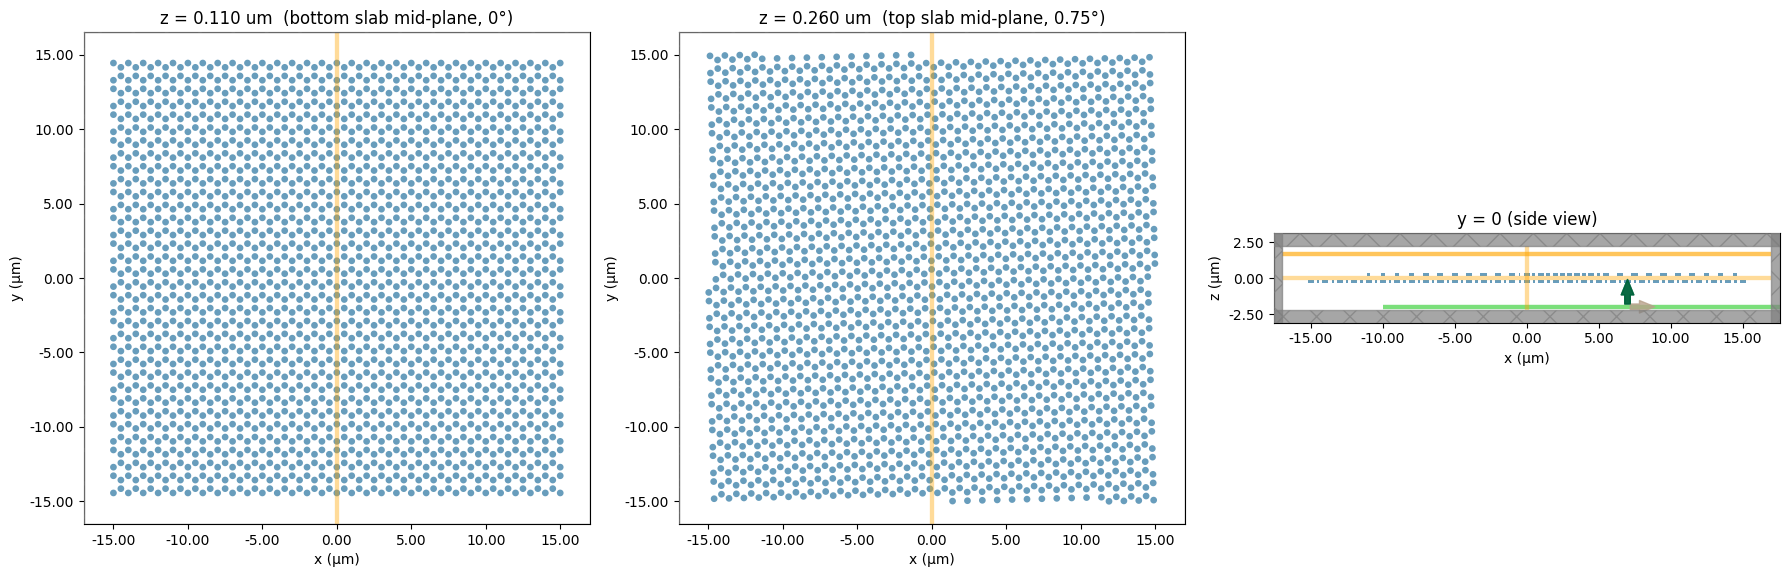

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# x-y at mid-plane of bottom slab
sim.plot(z=-z_span / 2 - GAP / 2, ax=axes[0])
axes[0].set_xlim(-lx / 2, lx / 2)
axes[0].set_ylim(-ly / 2, ly / 2)
axes[0].set_title(f"z = {z_span/2:.3f} um  (bottom slab mid-plane, 0°)")

# x-y at mid-plane of top slab
z_top_mid = z_span / 2 + GAP / 2
sim.plot(z=z_top_mid, ax=axes[1])
axes[1].set_xlim(-lx / 2, lx / 2)
axes[1].set_ylim(-ly / 2, ly / 2)
axes[1].set_title(f"z = {z_top_mid:.3f} um  (top slab mid-plane, {ANGLE}°)")

# x-z side view
sim.plot(y=0.5, ax=axes[2])
axes[2].set_title("y = 0 (side view)")

plt.tight_layout()
plt.show()

In [31]:
job = web.Job(simulation=sim, task_name="JieYao_v11", verbose=True)
estimated_cost = web.estimate_cost(job.task_id)
print(f'\n The estimated maximum cost is {estimated_cost:.3f} FlexCredits.')

02:23:15 Pacific Daylight Time Created task 'JieYao_v11' with resource_id       
                               'fdve-321429e5-9ffb-4d45-b5e8-688879aff06f' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=872847;https://tidy3d.simulation.cloud/workbench?taskId=fdve-321429e5-9ffb-4d45-b5e8-688879aff06f\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=769954;https://tidy3d.simulation.cloud/workbench?taskId=fdve-321429e5-9ffb-4d45-b5e8-688879aff06f\taskId]8;;\
                               ]8;id=872847;https://tidy3d.simulation.cloud/workbench?taskId=fdve-321429e5-9ffb-4d45-b5e8-688879aff06f\=]8;;\]8;id=627728;https://tidy3d.simulation.cloud/workbench?taskId=fdve-321429e5-9ffb-4d45-b5e8-688879aff06f\fdve]8;;\]8;id=872847;https://tidy3d.simulation.cloud/workbench?taskId=fdve-321429e5-9ffb-4d45-b5e8-688879aff06f\-321429e5-9ffb-4d45-b5e8-688879aff06f']8;;\.

                               Task folder: ]8;id=984367;https://tidy3d.simulation.cloud/folders/folder-401c0a0c-8e13-4a51-9b19-e6b8ae1b963e\'default']8;;\.

d:\13700k-01 Project\twistedPCS\.venv\Lib\site-packages\rich\live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

02:23:22 Pacific Daylight Time Estimated FlexCredit cost: 1.718. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.


 The estimated maximum cost is 1.718 FlexCredits.


In [ ]:
import datetime

# job = web.Job(simulation=sim, task_name="L3_opt", verbose=True)
sim_data = job.run(path="data/JieYao_v11.hdf5")

# Log task_id to file
task_id = job.task_id
timestamp = datetime.datetime.now().isoformat()
log_entry = f"{timestamp}\ttask_name=JieYao_v11\ttask_id={task_id}\n"
with open("data/task_log_JieYao.txt", "a") as f:
    f.write(log_entry)
print(log_entry.strip())

02:35:38 Pacific Daylight Time Estimated FlexCredit cost: 1.718. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

02:35:40 Pacific Daylight Time status = queued

                               To cancel the simulation, use                    
                               'web.abort(task_id)' or 'web.delete(task_id)' or 
                               abort/delete the task in the web UI. Terminating 
                               the Python script will not stop the job running  
                               on the cloud.

02:35:45 Pacific Daylight Time status = preprocess

02:35:50 Pacific Daylight Time starting up solver

02:35:51 Pacific Daylight Time running solver

02:37:36 Pacific Daylight Time status = postprocess

02:37:47 Pacific Daylight Time status = success

02:37:49 Pacific Daylight Time View simulation result at                        
                               ]8;id=273559;https://tidy3d.simulation.cloud/workbench?taskId=fdve-321429e5-9ffb-4d45-b5e8-688879aff06f\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=556005;https://tidy3d.simulation.cloud/workbench?taskId=fdve-321429e5-9ffb-4d45-b5e8-688879aff06f\taskId]8;;\
                               ]8;id=273559;https://tidy3d.simulation.cloud/workbench?taskId=fdve-321429e5-9ffb-4d45-b5e8-688879aff06f\=]8;;\]8;id=200705;https://tidy3d.simulation.cloud/workbench?taskId=fdve-321429e5-9ffb-4d45-b5e8-688879aff06f\fdve]8;;\]8;id=273559;https://tidy3d.simulation.cloud/workbench?taskId=fdve-321429e5-9ffb-4d45-b5e8-688879aff06f\-321429e5-9ffb-4d45-b5e8-688879aff06f']8;;\.

In [10]:
# sim_data = web.load(task_id="fdve-10d8a995-c992-477f-860a-dd7800004c9a", path="data/JieYao_v5.hdf5", verbose=True)
sim_data = td.SimulationData.from_file("data/JieYao_v11.hdf5")

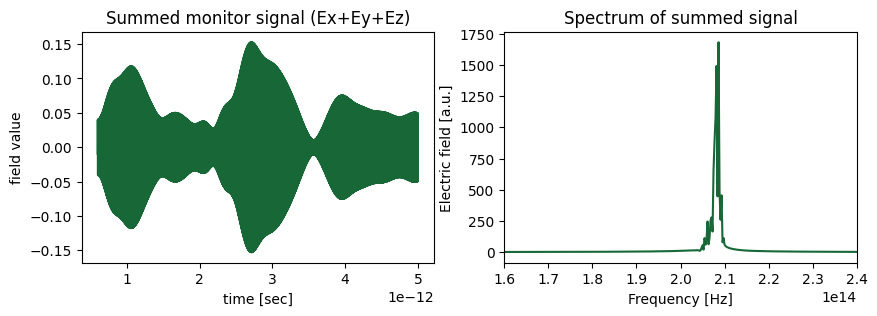

In [11]:
# Sum Ex + Ey + Ez across all randomized point monitors.
time_monitor_names = [mnt.name for mnt in time_series_mnts]

summed_signal = None
for name in time_monitor_names:
    tdata = sim_data[name]
    signal_xyz = tdata.Ex.squeeze() + tdata.Ey.squeeze() + tdata.Ez.squeeze()
    summed_signal = signal_xyz if summed_signal is None else (summed_signal + signal_xyz)

# Optional normalization by number of monitors.
time_series = summed_signal / len(time_monitor_names)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plot time dependence
time_series.plot(ax=ax1)
ax1.set_title("Summed monitor signal (Ex+Ey+Ez)")

# Make frequency mesh and plot spectrum
dt = sim_data.simulation.dt
fmesh = np.linspace(-1 / dt / 2, 1 / dt / 2, time_series.size)
spectrum = np.fft.fftshift(np.fft.fft(time_series))

ax2.plot(fmesh, np.abs(spectrum))
ax2.set_xlim(1.6e14, 2.4e14)
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Electric field [a.u.]")
ax2.set_title("Spectrum of summed signal")
plt.show()

In [12]:
resonance_finder = ResonanceFinder(freq_window=(1.8e14, 2.4e14), init_num_freqs=100)
# ResonanceFinder takes monitor data directly; use one representative monitor for fitting.
resonance_data = resonance_finder.run(sim_data[time_monitor_names[0]])
resonance_data.to_dataframe()

,decay,Q,amplitude,phase,error
freq,,,,,
2.042295e+14,1.356618e+12,472.945203,0.003079,2.435212,0.002591
2.049738e+14,-1.898706e+11,-3391.489642,0.000175,2.726139,0.003581
2.053193e+14,8.417636e+11,766.283747,0.045006,2.224007,0.003070
2.056323e+14,1.499389e+12,430.850797,0.045327,0.478690,0.007302
2.060446e+14,-1.575867e+10,-41076.323303,0.012462,-0.922604,0.004646
2.062356e+14,-1.858605e+10,-34859.925881,0.008991,0.899955,0.003821
2.069810e+14,7.684919e+11,846.137727,0.052398,-1.475053,0.001768
2.074793e+14,3.950484e+11,1649.963355,0.093867,-2.254747,0.000926
2.080104e+14,5.072742e+11,1288.226237,0.198471,0.139065,0.001606


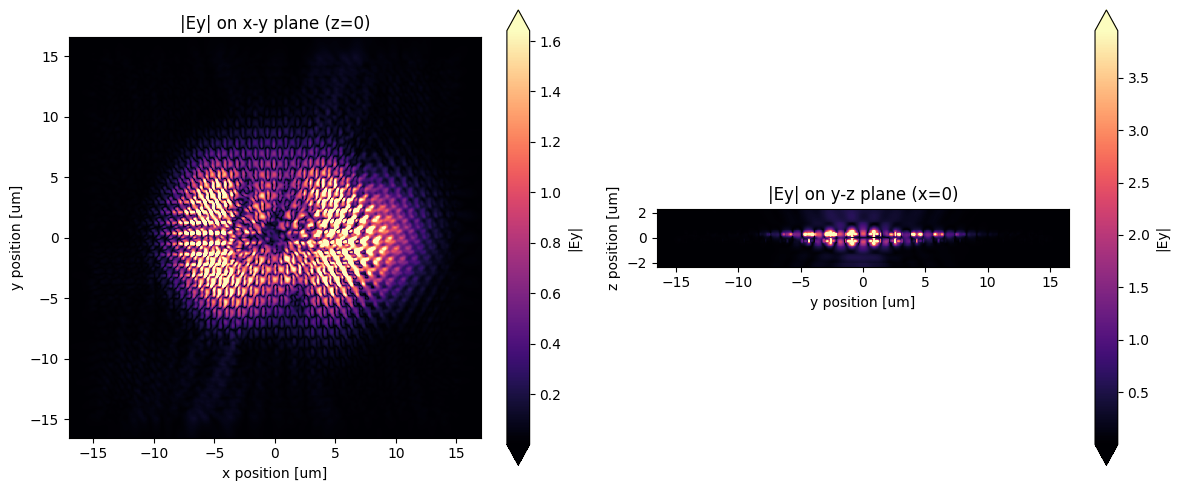

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sim_data.plot_field("field_xy", "Ey", val="abs", z=0, ax=axes[0], eps_alpha=0)
axes[0].set_title("|Ey| on x-y plane (z=0)")

sim_data.plot_field("field_x0", "Ey", val="abs", x=0, ax=axes[1], eps_alpha=0)
axes[1].set_title("|Ey| on y-z plane (x=0)")

plt.tight_layout()
plt.show()

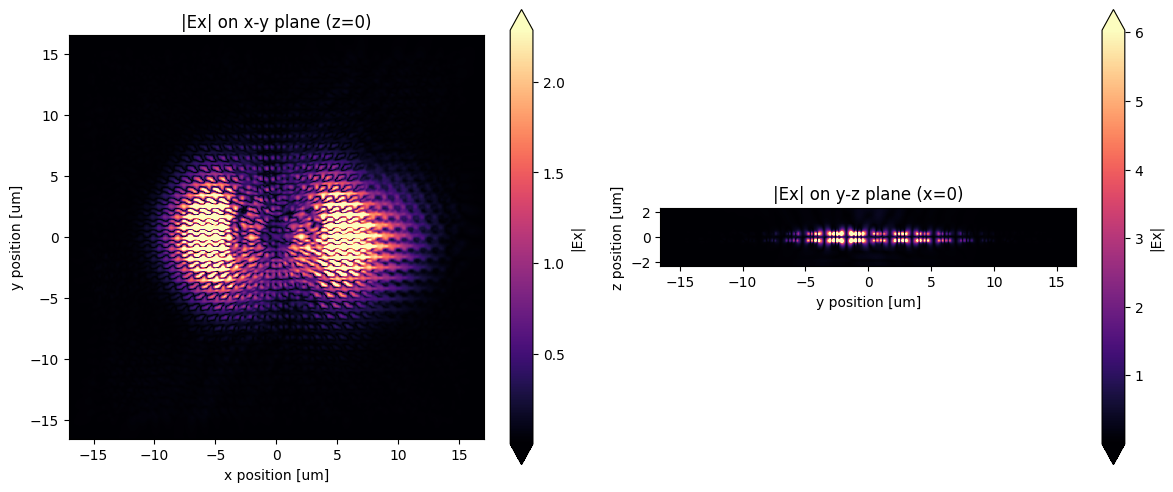

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sim_data.plot_field("field_xy", "Ex", val="abs", z=0, ax=axes[0], eps_alpha=0)
axes[0].set_title("|Ex| on x-y plane (z=0)")

sim_data.plot_field("field_x0", "Ex", val="abs", x=0, ax=axes[1], eps_alpha=0)
axes[1].set_title("|Ex| on y-z plane (x=0)")

plt.tight_layout()
plt.show()

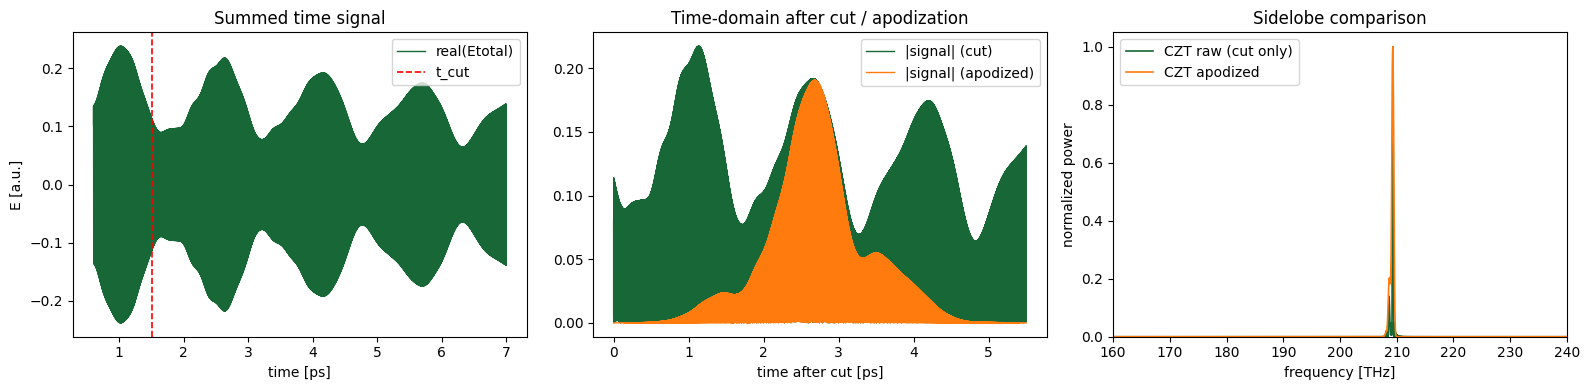

Applied t_cut = 1.50e-12 s, apod_width = 0.125, apod_center = 0.5
Use the apodized curve to assess sidelobe suppression around the main resonances.


In [21]:
# Lumerical-style sidelobe suppression analysis:
# 1) sum Ex+Ey+Ez over monitors,
# 2) remove initial transient (first 1.5e-12 s),
# 3) apply Gaussian apodization,
# 4) compute spectrum in a target band via CZT.

from scipy.signal import czt

# ---- user-tunable parameters ----
t_cut = 1.5e-12
apod_width = 0.125
apod_center = 0.5
f1, f2 = 1.6e14, 2.4e14
n_freq = 5000

# ---- aggregate monitor fields: Etotal = sum_j (Ex_j + Ey_j + Ez_j) ----
if "time_monitor_names" not in globals():
    time_monitor_names = [mnt.name for mnt in time_series_mnts]

Etotal = None
for name in time_monitor_names:
    mdat = sim_data[name]
    sig = mdat.Ex.squeeze() + mdat.Ey.squeeze() + mdat.Ez.squeeze()
    Etotal = sig if Etotal is None else (Etotal + sig)

# optional average over monitors for scale consistency
Etotal = Etotal / len(time_monitor_names)

# time axis from monitor data
if "t" in Etotal.coords:
    t = np.asarray(Etotal.coords["t"].values, dtype=float)
else:
    t = np.arange(Etotal.size) * float(sim_data.simulation.dt)

signal = np.asarray(Etotal.values, dtype=complex)

# ---- remove initial transient ----
mask = t >= t_cut
if mask.sum() < 10:
    raise RuntimeError("Too few samples remain after t_cut. Reduce t_cut or increase run_time.")

t_sel = t[mask]
sig_sel = signal[mask]

# shift time origin for cleaner phase behavior
tr = t_sel - t_sel[0]
Tmax = tr.max()

# ---- Gaussian apodization (same form as provided Lumerical snippet) ----
# signal *= exp( -0.5 * (t - Tmax*apod_center)^2 / (apod_width*Tmax)^2 )
if Tmax <= 0:
    raise RuntimeError("Selected time window has zero duration.")

denom = (apod_width * Tmax) ** 2
window = np.exp(-0.5 * ((tr - Tmax * apod_center) ** 2) / denom)
sig_apod = sig_sel * window

# ---- CZT on [f1, f2] with n_freq points ----
dt_sel = float(np.median(np.diff(tr)))
f = np.linspace(f1, f2, n_freq)
df = f[1] - f[0]
a = np.exp(1j * 2 * np.pi * f1 * dt_sel)
w = np.exp(-1j * 2 * np.pi * df * dt_sel)

fd_raw = np.abs(czt(sig_sel, m=n_freq, w=w, a=a)) ** 2
fd_apod = np.abs(czt(sig_apod, m=n_freq, w=w, a=a)) ** 2

# normalize for sidelobe comparison
fd_raw_n = fd_raw / np.max(fd_raw)
fd_apod_n = fd_apod / np.max(fd_apod)

# ---- plots ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(t * 1e12, np.real(signal), lw=1.0, label="real(Etotal)")
axes[0].axvline(t_cut * 1e12, color="r", ls="--", lw=1.2, label="t_cut")
axes[0].set_xlabel("time [ps]")
axes[0].set_ylabel("E [a.u.]")
axes[0].set_title("Summed time signal")
axes[0].legend()

axes[1].plot(tr * 1e12, np.abs(sig_sel), lw=1.0, label="|signal| (cut)")
axes[1].plot(tr * 1e12, np.abs(sig_apod), lw=1.0, label="|signal| (apodized)")
axes[1].set_xlabel("time after cut [ps]")
axes[1].set_title("Time-domain after cut / apodization")
axes[1].legend()

axes[2].plot(f * 1e-12, fd_raw_n, lw=1.2, label="CZT raw (cut only)")
axes[2].plot(f * 1e-12, fd_apod_n, lw=1.2, label="CZT apodized")
axes[2].set_xlabel("frequency [THz]")
axes[2].set_ylabel("normalized power")
axes[2].set_title("Sidelobe comparison")
axes[2].set_xlim(f1 * 1e-12, f2 * 1e-12)
axes[2].set_ylim(0, 1.05)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Applied t_cut = {t_cut:.2e} s, apod_width = {apod_width}, apod_center = {apod_center}")
print("Use the apodized curve to assess sidelobe suppression around the main resonances.")

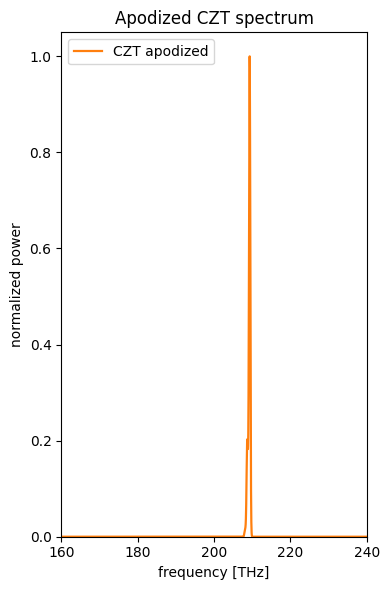

In [22]:
# Plot only the CZT-apodized spectrum and run ResonanceFinder on apodized signal.

import xarray as xr

# 1) CZT-apodized spectrum only
plt.figure(figsize=(4, 6))
plt.plot(f * 1e-12, fd_apod_n, lw=1.6, color="tab:orange", label="CZT apodized")
plt.xlim(f1 * 1e-12, f2 * 1e-12)
plt.ylim(0, 1.05)
plt.xlabel("frequency [THz]")
plt.ylabel("normalized power")
plt.title("Apodized CZT spectrum")
plt.legend()
plt.tight_layout()
plt.show()

In [46]:


# 2) ResonanceFinder on apodized time signal
# Build a full-length apodization window to keep array shape compatible with monitor data.
ref_mdat = sim_data[time_monitor_names[0]]
t_full = np.asarray(ref_mdat.Ex.coords["t"].values, dtype=float)

window_full = np.zeros_like(t_full, dtype=float)
mask_full = t_full >= t_cut

if mask_full.sum() < 10:
    raise RuntimeError("Too few samples remain after t_cut for ResonanceFinder.")

t_after = t_full[mask_full] - t_full[mask_full][0]
T_after = t_after.max()
if T_after <= 0:
    raise RuntimeError("Selected post-cut window has zero duration.")

window_after = np.exp(-0.5 * ((t_after - T_after * apod_center) ** 2) / ((apod_width * T_after) ** 2))
window_full[mask_full] = window_after

window_da = xr.DataArray(window_full, coords={"t": ref_mdat.Ex.coords["t"]}, dims=["t"])

# Apply same temporal window to all E components so ResonanceFinder can use field data.
Ex_apod = ref_mdat.Ex * window_da
Ey_apod = ref_mdat.Ey * window_da
Ez_apod = ref_mdat.Ez * window_da

# Build an apodized FieldTimeData object (compatible with ResonanceFinder.run).
try:
    apodized_field = ref_mdat.updated_copy(Ex=Ex_apod, Ey=Ey_apod, Ez=Ez_apod)
except Exception:
    apodized_field = ref_mdat.copy(update={"Ex": Ex_apod, "Ey": Ey_apod, "Ez": Ez_apod})

resonance_finder_apod = ResonanceFinder(freq_window=(f1, f2), init_num_freqs=100)
resonance_data_apod = resonance_finder_apod.run(apodized_field)

resonance_df_apod = resonance_data_apod.to_dataframe()

# Handle both output styles: frequency as a column or as index.
if "freq" in resonance_df_apod.columns:
    freq_vals = resonance_df_apod["freq"].to_numpy()
else:
    freq_vals = resonance_df_apod.index.to_numpy()

resonance_df_apod = resonance_df_apod.copy()
resonance_df_apod["freq_THz"] = freq_vals * 1e-12

# Keep only columns that exist in this tidy3d version.
show_cols = [c for c in ["freq_THz", "Q", "amplitude", "phase", "error"] if c in resonance_df_apod.columns]

print("Resonances from apodized monitor signal:")
display(resonance_df_apod[show_cols].sort_values("freq_THz"))

Resonances from apodized monitor signal:


,freq_THz,Q,amplitude,phase,error
freq,,,,,
1.837504e+14,183.750371,199.868407,1.101909e-06,2.427269,0.001460
1.857552e+14,185.755221,-132.217192,5.863381e-08,1.768728,0.000588
1.866633e+14,186.663349,-12.500610,1.656536e-05,2.233420,0.002639
1.883135e+14,188.313470,-490.052649,6.657973e-09,-2.207054,0.000327
1.887195e+14,188.719493,-416.955442,4.605011e-07,2.664006,0.000284
1.900513e+14,190.051328,-330.596134,1.834063e-06,2.020454,0.000222
1.903969e+14,190.396907,-301.306031,1.390423e-06,0.361633,0.000186
1.907279e+14,190.727917,-288.475277,8.933535e-07,-1.116706,0.000113
1.913822e+14,191.382230,-268.272097,7.496858e-07,-0.413585,0.000144


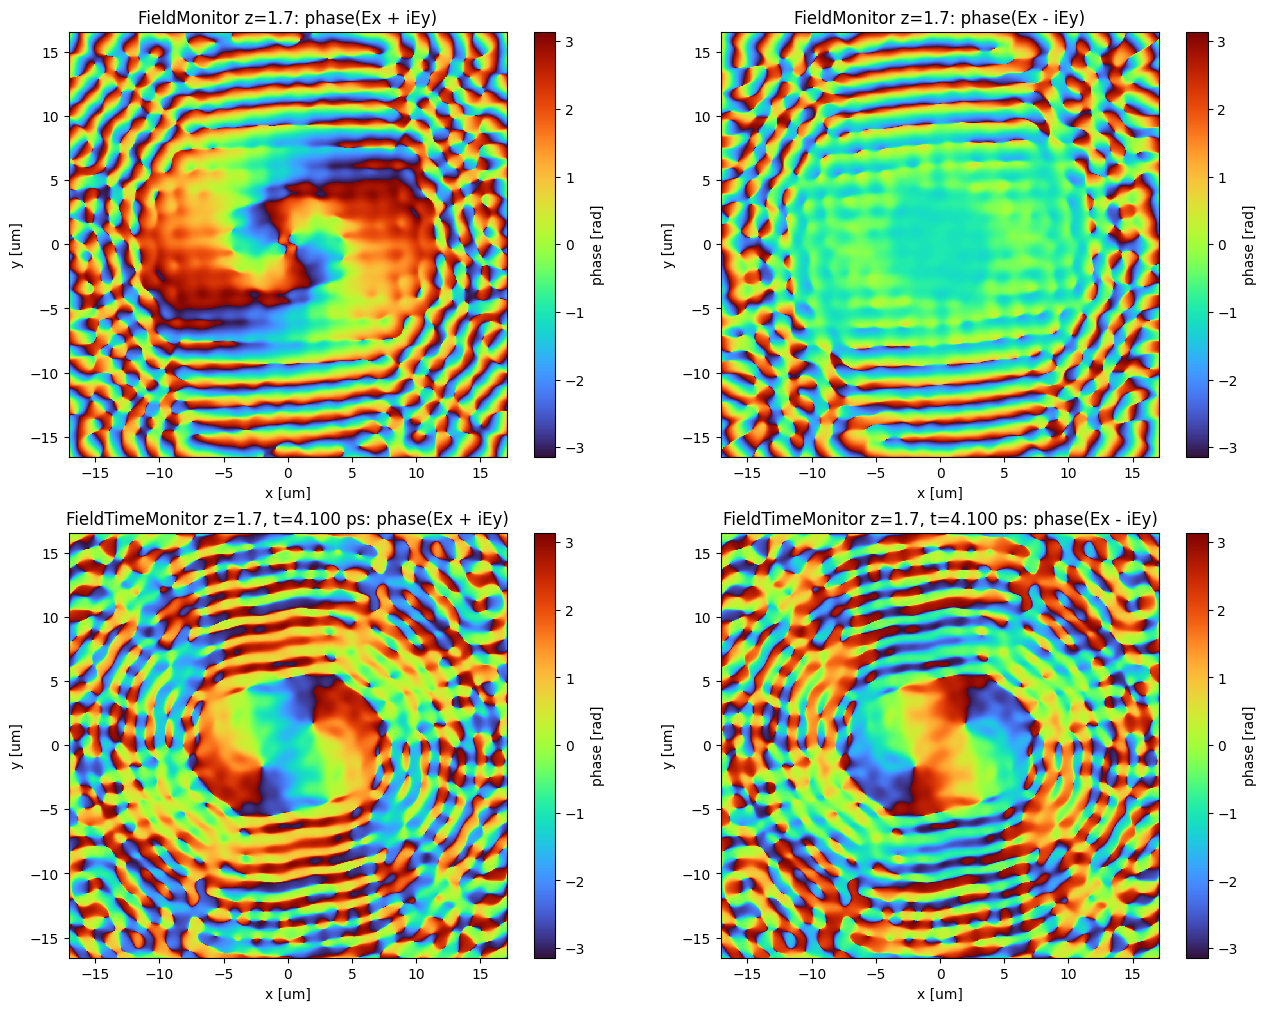

Selected frame index 7 for requested time t_pick=4.000e-12 s (actual t=4.100e-12 s)


In [25]:
# Phase maps of circular polarization components at z = 1.7 um.
# 1) From frequency-domain FieldMonitor: field_xy_z17
# 2) From time-domain FieldTimeMonitor: field_xy_t_z17 at manually selected time

# ---------- helper ----------
def circular_phase_maps(ex_da, ey_da):
    sigma_plus = ex_da + 1j * ey_da
    sigma_minus = ex_da - 1j * ey_da
    return np.angle(sigma_plus), np.angle(sigma_minus)

# ---------- fetch monitor data ----------
try:
    field_xy_z17_data = sim_data["field_xy_z17"]
    field_xy_t_z17_data = sim_data["field_xy_t_z17"]
except Exception as exc:
    raise RuntimeError(
        "Required monitors field_xy_z17 / field_xy_t_z17 not found in sim_data. "
        "Re-run the simulation and reload the new output file."
    ) from exc

# ---------- frequency-domain monitor ----------
Ex_fd = field_xy_z17_data.Ex.squeeze()
Ey_fd = field_xy_z17_data.Ey.squeeze()
phase_plus_fd, phase_minus_fd = circular_phase_maps(Ex_fd, Ey_fd)

x_vals = np.asarray(Ex_fd.coords["x"].values, dtype=float)
y_vals = np.asarray(Ex_fd.coords["y"].values, dtype=float)

# ---------- time-domain monitor ----------
# Manually set the time you want to visualize.
t_pick = 4e-12

# Pick the nearest recorded frame in the monitor time grid.
t_vals = np.asarray(field_xy_t_z17_data.Ex.coords["t"].values, dtype=float)
t_idx = int(np.argmin(np.abs(t_vals - t_pick)))
t_sel = t_vals[t_idx]

Ex_td = field_xy_t_z17_data.Ex.isel(t=t_idx).squeeze()
Ey_td = field_xy_t_z17_data.Ey.isel(t=t_idx).squeeze()
phase_plus_td, phase_minus_td = circular_phase_maps(Ex_td, Ey_td)

# ---------- plotting ----------
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

im0 = axes[0, 0].pcolormesh(x_vals, y_vals, np.asarray(phase_plus_fd).T, shading="auto", cmap="turbo", vmin=-np.pi, vmax=np.pi)
axes[0, 0].set_title("FieldMonitor z=1.7: phase(Ex + iEy)")
axes[0, 0].set_xlabel("x [um]")
axes[0, 0].set_ylabel("y [um]")
axes[0, 0].set_aspect("equal")
fig.colorbar(im0, ax=axes[0, 0], label="phase [rad]")

im1 = axes[0, 1].pcolormesh(x_vals, y_vals, np.asarray(phase_minus_fd).T, shading="auto", cmap="turbo", vmin=-np.pi, vmax=np.pi)
axes[0, 1].set_title("FieldMonitor z=1.7: phase(Ex - iEy)")
axes[0, 1].set_xlabel("x [um]")
axes[0, 1].set_ylabel("y [um]")
axes[0, 1].set_aspect("equal")
fig.colorbar(im1, ax=axes[0, 1], label="phase [rad]")

im2 = axes[1, 0].pcolormesh(x_vals, y_vals, np.asarray(phase_plus_td).T, shading="auto", cmap="turbo", vmin=-np.pi, vmax=np.pi)
axes[1, 0].set_title(f"FieldTimeMonitor z=1.7, t={t_sel*1e12:.3f} ps: phase(Ex + iEy)")
axes[1, 0].set_xlabel("x [um]")
axes[1, 0].set_ylabel("y [um]")
axes[1, 0].set_aspect("equal")
fig.colorbar(im2, ax=axes[1, 0], label="phase [rad]")

im3 = axes[1, 1].pcolormesh(x_vals, y_vals, np.asarray(phase_minus_td).T, shading="auto", cmap="turbo", vmin=-np.pi, vmax=np.pi)
axes[1, 1].set_title(f"FieldTimeMonitor z=1.7, t={t_sel*1e12:.3f} ps: phase(Ex - iEy)")
axes[1, 1].set_xlabel("x [um]")
axes[1, 1].set_ylabel("y [um]")
axes[1, 1].set_aspect("equal")
fig.colorbar(im3, ax=axes[1, 1], label="phase [rad]")

plt.show()
print(f"Selected frame index {t_idx} for requested time t_pick={t_pick:.3e} s (actual t={t_sel:.3e} s)")